#### POREĐENJE MODELA

U ovoj svesci poredimo rezultate prethodno istreniranih modela:
- Baseline CNN model
- Metric learning model sa Triplet Loss funkcijom i KNN klasifikatorom
- Transfer learning model sa pretreniranim ResNet18 modelom

Modeli se porede na istom test skupu, uz iste metrike:
accuracy, precision, recall i F1-score.

In [53]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

In [54]:
base_dir = Path("../data/tomatoleaf/tomato")

train_dir = base_dir / "train"
test_dir = base_dir / "val"

baseline_model_path = Path("baseline_cnn_best.pth")
metric_model_path = Path("best_embedding_cnn_triplet.pth")
transfer_model_path = Path("transfer_learning_resnet18_best.pth")

print("Train dir:", train_dir.resolve())
print("Test dir:", test_dir.resolve())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

print("Baseline model exists:", baseline_model_path.exists())
print("Metric learning model exists:", metric_model_path.exists())
print("Transfer learning model exists:", transfer_model_path.exists())

IMG_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
EMBEDDING_DIM = 64
DROPOUT_RATE = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Train dir: C:\Users\User\Desktop\ML_projekat\data\tomatoleaf\tomato\train
Test dir: C:\Users\User\Desktop\ML_projekat\data\tomatoleaf\tomato\val
Train exists: True
Test exists: True
Baseline model exists: True
Metric learning model exists: True
Transfer learning model exists: True
Device: cpu


In [55]:
def add_windows_long_path_prefix(path):
    """
    Na Windowsu neki fajlovi iz ovog dataset-a imaju jako duga imena.
    Ako je apsolutna putanja duža od Windows MAX_PATH ograničenja, open() može da prijavi
    FileNotFoundError iako fajl stvarno postoji. Prefiks \\?\ omogućava čitanje dugih putanja.
    Na Linuxu/macOS-u funkcija samo vraća običnu putanju.
    """
    path = Path(path).resolve()
    path_str = str(path)

    if os.name == "nt":
        if path_str.startswith("\\\\"):
            return "\\\\?\\UNC\\" + path_str.lstrip("\\")
        return "\\\\?\\" + path_str

    return path_str


def pil_loader_safe(path):
    """
    Loader za torchvision ImageFolder.
    Koristi Windows long-path prefiks i konvertuje sve slike u RGB.
    """
    with open(add_windows_long_path_prefix(path), "rb") as f:
        image = Image.open(f)
        return image.convert("RGB")


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [56]:
full_train_dataset = datasets.ImageFolder(
    root=str(train_dir),
    transform=transform,
    loader=pil_loader_safe
)

test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=transform,
    loader=pil_loader_safe
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Klase:", class_names)
print("Broj klasa:", num_classes)
print("Broj slika u originalnom train skupu:", len(full_train_dataset))
print("Broj slika u test skupu:", len(test_dataset))

Klase: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Broj klasa: 10
Broj slika u originalnom train skupu: 10000
Broj slika u test skupu: 1000


In [57]:
val_size = int(len(full_train_dataset) * VALIDATION_SPLIT)
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Validation size: 2000
Test size: 1000


Za poređenje modela u DataLoader-e stavljamo parametar shuffle=False, jer ovde ne treniramo, nego samo evaluiramo modele.

In [58]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

Moramo da iskopiramo klase modela u ovu svesku, da bismo mogle da učitamo najbolje modele.

#### Klasa za Baseline CNN model

In [59]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = self.global_pool(x)
        x = torch.flatten(x, 1)

        x = self.dropout(x)
        x = self.fc(x)

        return x

#### Klasa za Metric Learning model

In [60]:
class EmbeddingCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT_RATE),
            nn.Linear(512, embedding_dim)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)
        return x

#### Klasa za Transfer Learning model

In [61]:
def create_resnet18_transfer_model(num_classes):
    try:
        weights = ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except:
        model = models.resnet18(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    return model

#### Pomoćne funkcije za evaluaciju i računanje metrika

In [62]:
def evaluate_classifier(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_predictions.extend(predicted.cpu().numpy())

    return np.array(all_labels), np.array(all_predictions)


def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

#### Učitavanje najboljeg Baseline CNN modela

In [63]:
baseline_model = BaselineCNN(
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

baseline_model.load_state_dict(
    torch.load(baseline_model_path, map_location=device)
)

baseline_model.eval()

baseline_y_true, baseline_y_pred = evaluate_classifier(
    baseline_model,
    test_loader,
    device
)

baseline_metrics = calculate_metrics(baseline_y_true, baseline_y_pred)

baseline_metrics

{'accuracy': 0.841,
 'precision': 0.8582873379024332,
 'recall': 0.841,
 'f1_score': 0.8403914973373569}

#### Učitavanje Metric Learning modela i KNN evaluacija

Pošto metric learning model ne daje direktno klase, nego embeddinge, ovde radimo:

- učitavanje embedding modela;
- izvlačimo embeddinge za train skup;
- izvlačimo embeddinge za test skup;
- treniramo KNN nad izvučenim train embedding;
- evaluiramo KNN nad izvučenim test embedding.

In [64]:
def extract_embeddings_standard(model, loader, device):
    model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for images, label in loader:
            images = images.to(device)

            emb = model(images)

            embeddings.append(emb.cpu().numpy())
            labels.append(label.numpy())

    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    return embeddings, labels

In [65]:
embedding_model = EmbeddingCNN(
    embedding_dim=EMBEDDING_DIM
).to(device)

embedding_model.load_state_dict(
    torch.load(metric_model_path, map_location=device)
)

embedding_model.eval()

train_emb, train_labels = extract_embeddings_standard(
    embedding_model,
    train_loader,
    device
)

test_emb, test_labels = extract_embeddings_standard(
    embedding_model,
    test_loader,
    device
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_emb, train_labels)

knn_y_pred = knn.predict(test_emb)
knn_y_true = test_labels

knn_metrics = calculate_metrics(knn_y_true, knn_y_pred)

knn_metrics

{'accuracy': 0.822,
 'precision': 0.8219920979665979,
 'recall': 0.822,
 'f1_score': 0.8215756737698924}

#### Učitavanje Transfer Learning modela

In [66]:
transfer_model = create_resnet18_transfer_model(
    num_classes=num_classes
).to(device)

transfer_model.load_state_dict(
    torch.load(transfer_model_path, map_location=device)
)

transfer_model.eval()

transfer_y_true, transfer_y_pred = evaluate_classifier(
    transfer_model,
    test_loader,
    device
)

transfer_metrics = calculate_metrics(
    transfer_y_true,
    transfer_y_pred
)

transfer_metrics

C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


{'accuracy': 0.867,
 'precision': 0.8723051230597046,
 'recall': 0.867,
 'f1_score': 0.8669414022791678}

#### TABELARNO POREĐENJE MODELA

In [67]:
results_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        **baseline_metrics
    },
    {
        "Model": "Metric Learning + KNN",
        **knn_metrics
    },
    {
        "Model": "Transfer Learning ResNet18",
        **transfer_metrics
    }
])

results_df

,Model,accuracy,precision,recall,f1_score
0,Baseline CNN,0.841,0.858287,0.841,0.840391
1,Metric Learning + KNN,0.822,0.821992,0.822,0.821576
2,Transfer Learning ResNet18,0.867,0.872305,0.867,0.866941


In [68]:
#LEPŠI ISPIS - PROBAJ KASNIJE
#results_df_rounded = results_df.copy()

#for col in ["accuracy", "precision", "recall", "f1_score"]:
#    results_df_rounded[col] = results_df_rounded[col].round(4)

#results_df_rounded

#### GRAFIČKO POREĐENJE MODELA

<Figure size 1000x600 with 0 Axes>

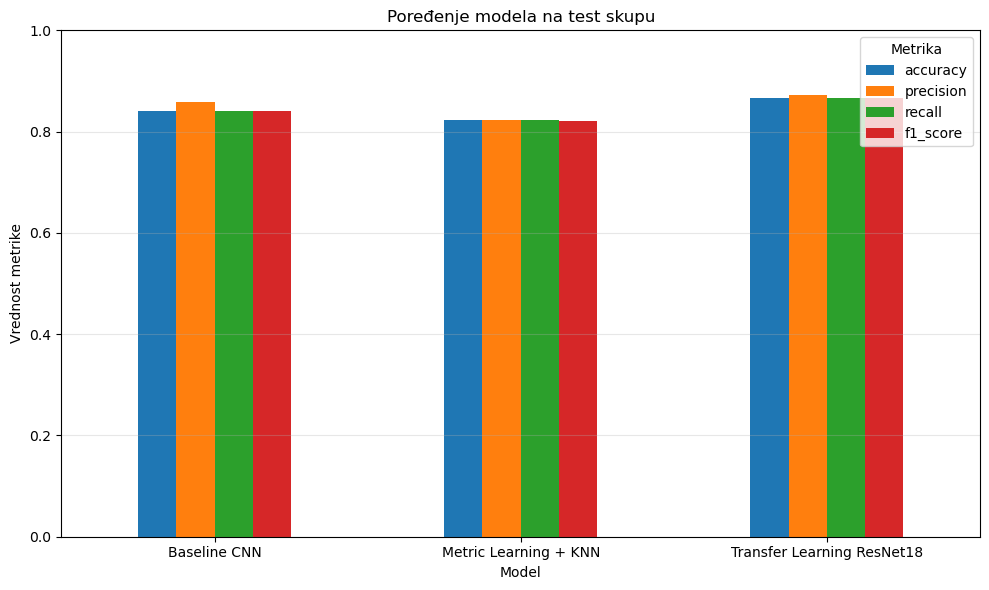

In [69]:
plot_df = results_df.set_index("Model")

plt.figure(figsize=(10, 6))
plot_df[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", figsize=(10, 6))

plt.title("Poređenje modela na test skupu")
plt.ylabel("Vrednost metrike")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrika")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### CLASSIFICATION REPORT

#### Baseline CNN model

In [70]:
print("Baseline CNN classification report:")
print(classification_report(
    baseline_y_true,
    baseline_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Baseline CNN classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.85      0.90      0.87       100
                        Early blight       0.84      0.64      0.73       100
                         Late blight       0.62      0.87      0.72       100
                           Leaf Mold       0.92      0.85      0.89       100
                  Septoria leaf spot       0.95      0.62      0.75       100
Spider mites Two-spotted spider mite       0.87      0.80      0.83       100
                         Target Spot       0.74      0.98      0.84       100
       Tomato Yellow Leaf Curl Virus       0.88      0.85      0.86       100
                 Tomato mosaic virus       0.95      1.00      0.98       100
                             healthy       0.96      0.90      0.93       100

                            accuracy                           0.84      1000
                          

#### Metric Learning model

In [71]:
print("Metric Learning + KNN classification report:")
print(classification_report(
    knn_y_true,
    knn_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Metric Learning + KNN classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.83      0.89      0.86       100
                        Early blight       0.77      0.81      0.79       100
                         Late blight       0.75      0.70      0.73       100
                           Leaf Mold       0.80      0.76      0.78       100
                  Septoria leaf spot       0.80      0.78      0.79       100
Spider mites Two-spotted spider mite       0.76      0.74      0.75       100
                         Target Spot       0.75      0.80      0.77       100
       Tomato Yellow Leaf Curl Virus       0.84      0.81      0.82       100
                 Tomato mosaic virus       0.98      0.97      0.97       100
                             healthy       0.95      0.96      0.96       100

                            accuracy                           0.82      1000
                 

#### Transfer Learning model

In [72]:
print("Transfer Learning ResNet18 classification report:")
print(classification_report(
    transfer_y_true,
    transfer_y_pred,
    target_names=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    zero_division=0
))

Transfer Learning ResNet18 classification report:
                                      precision    recall  f1-score   support

                      Bacterial spot       0.89      0.96      0.92       100
                        Early blight       0.76      0.83      0.79       100
                         Late blight       0.85      0.87      0.86       100
                           Leaf Mold       0.79      0.88      0.83       100
                  Septoria leaf spot       0.96      0.72      0.82       100
Spider mites Two-spotted spider mite       0.86      0.86      0.86       100
                         Target Spot       0.85      0.79      0.82       100
       Tomato Yellow Leaf Curl Virus       0.96      0.94      0.95       100
                 Tomato mosaic virus       0.82      0.91      0.86       100
                             healthy       0.98      0.91      0.94       100

                            accuracy                           0.87      1000
            

#### MATRICE KONFUZIJE

#### Baseline CNN model

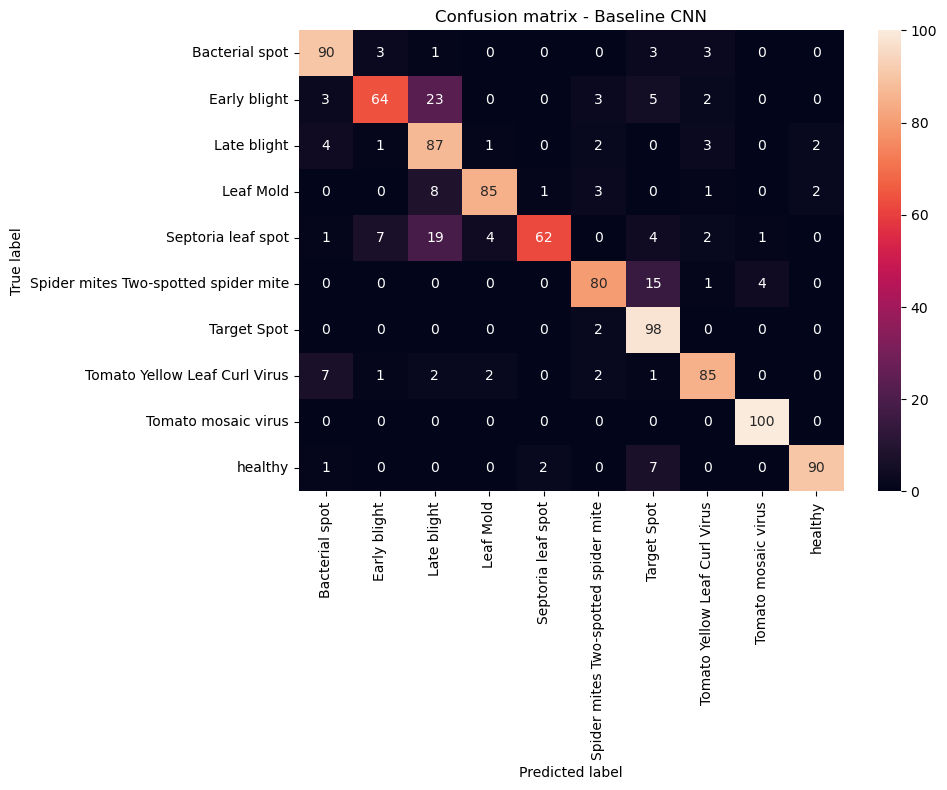

In [73]:
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Baseline CNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Metric Learning model

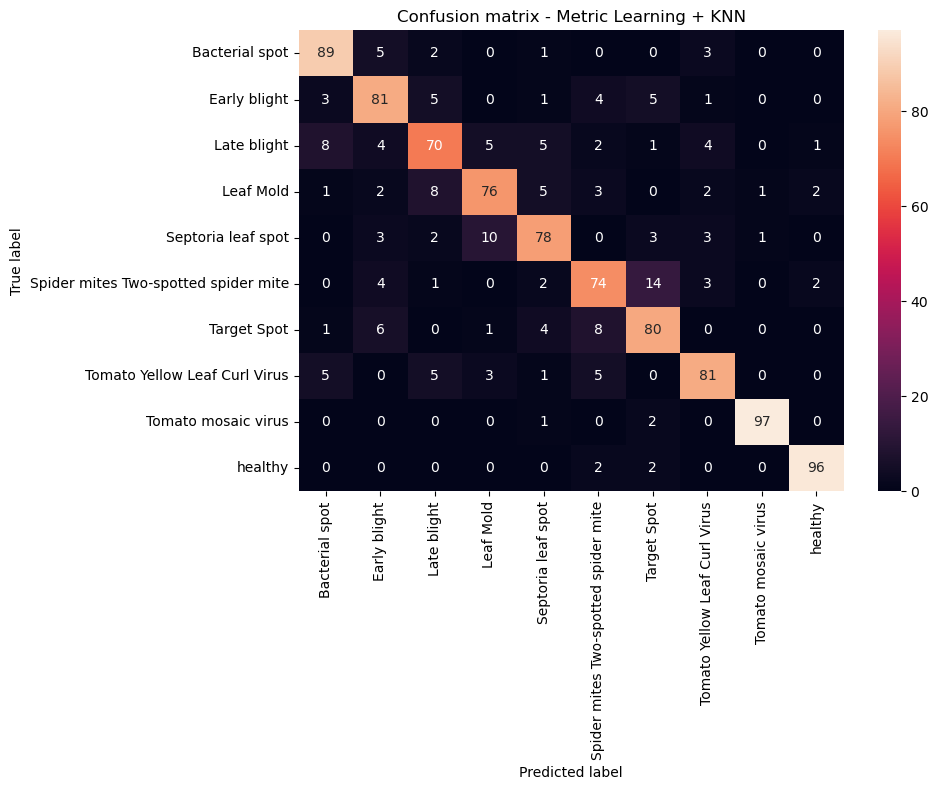

In [74]:
knn_cm = confusion_matrix(knn_y_true, knn_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Metric Learning + KNN")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Transfer Learning model

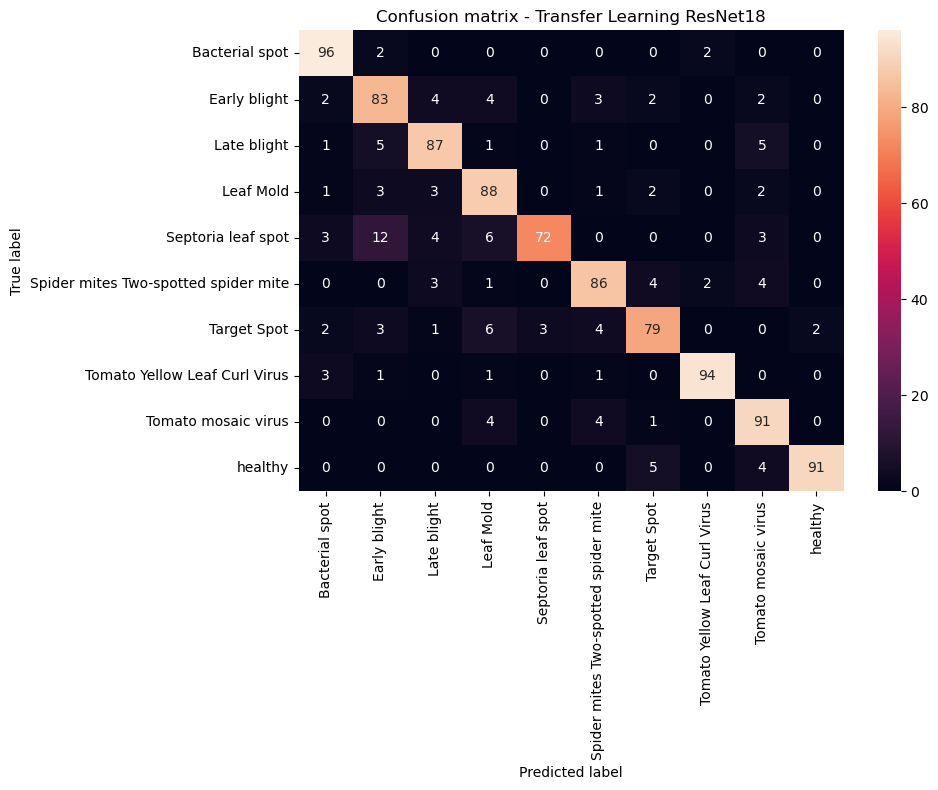

In [75]:
transfer_cm = confusion_matrix(transfer_y_true, transfer_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    transfer_cm,
    annot=True,
    fmt="d",
    xticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names],
    yticklabels=[cls.replace("Tomato___", "").replace("_", " ") for cls in class_names]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix - Transfer Learning ResNet18")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()